In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# <span style="color:#2a9d8fff"> **Part A**: Data Understanding & Cleaning</span> #

**Step 1**: Load the dataset into the `data` DataFrame and see the detailed data.

In [87]:
data = pd.read_excel('Project Data.xlsx', index_col=0)

In [88]:
#print(f"shape of the dataset: {data.shape}") NÃO SEI QUAL PREFEREM OU SE QUEREM DEIXAR AMBOS
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.")
data.head()

The dataset has 10008 rows and 15 columns.


,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
Patient ID,,,,,,,,,,,,,,,
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-02-22,Endocrinology,110,2,38839.0,293.014042,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-01-21,Emergency,76,4,52219.0,287.208982,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-06-13,Neurology,17,5,41491.0,241.254507,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-24,Emergency,15,3,34944.0,221.177483,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-19,Neurology,99,1,39248.0,219.743794,0.0


In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        9952 non-null   float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         8098 non-null   object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

**Step 2**: Check the quality of the data.

In [90]:
missing_count = data.isna().sum()
missing_percentage = (data.isna().mean()*100).round(2)
missing_summary = pd.DataFrame({'Count of Missing Values': missing_count, '% of Missing Values': missing_percentage}).sort_values(by = '% of Missing Values', ascending = False)
missing_summary

,Count of Missing Values,% of Missing Values
Family History,1993,19.91
Insurance Provider,1910,19.08
Approximate Annual Income,154,1.54
Age,56,0.56
Insurance Coverage,50,0.50
Education Level,29,0.29
Gender,0,0.00
City of Residence,0,0.00
Profession,0,0.00
Marital Status,0,0.00


The most problematic variable is `Family History` with 19.91% of missing values.

**Step 3**: Exploring Missingness Type (MCAR, MAR, MNAR)

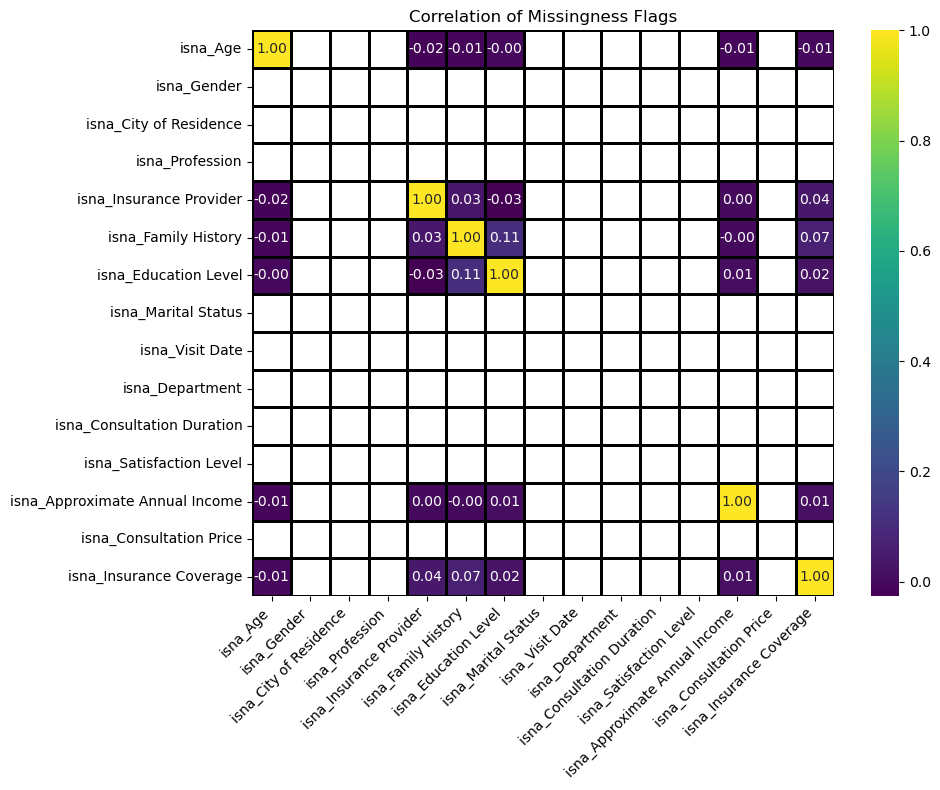

In [91]:
missing_flags = data.isna().astype(int).add_prefix("isna_")

# Compute "correlation of missingness flags" to see if missing patterns co-occur
corr_flags = missing_flags.corr()

# Visualize the correlation matrix of missingness flags
plt.figure(figsize=(10, 8))
sns.heatmap(corr_flags, annot=True, fmt=".2f", cmap="viridis", cbar=True, linewidths=1, linecolor='black')
plt.title("Correlation of Missingness Flags")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This shows that, for the majority of the variables, there is no correlation in their missingness, meaning the patter of missingness for those is unrelated to any variable. These missing values are **Missing Completely at Random (MCAR)**.

However, there are weak to moderate correlations between some variables:
- `isna_Family History` and `isna_Education Level` (corr = 0.11): this might indicate that if a patient's Family History is missing then there is a high probability the Education Level for that same patient will be missing too.
- `isna_Family History` and `isna_Insurance Coverage` (corr = 0.07): this might indicate that if a patient's Family History is missing then there is a high probability the Insurance Coverage for that same patient will be missing too.
- `isna_Insurance Provider` and `isna_Insurance Coverage` (corr = 0.04): this might indicate that if a patient's Insurance Provider is missing then there is a high probability the Insurance Coverage for that same patient will be missing too.

**Step 4**: Fill in the missing values for Age: inspect all cells of those patients and see if they have their age associated.

In [92]:
patients_with_nan_age = data.index[data['Age'].isna()].unique()

In [93]:
patients_rows = data.loc[data.index.isin(patients_with_nan_age)]
ages_of_patients = patients_rows.groupby(patients_rows.index)['Age'] \
                                      .apply(lambda x: x.dropna().iloc[0])
ages_of_patients

Patient ID
1009    20.0
1012     7.0
1023    82.0
1029    16.0
1031    71.0
1036    78.0
1048    98.0
1051    29.0
1057    42.0
1061    42.0
1065    55.0
1070    93.0
1084    98.0
1103    65.0
1108    57.0
1109     2.0
1112    94.0
1117    79.0
1118    52.0
1125    65.0
1128    91.0
1139    35.0
1144    89.0
1154    48.0
1175    82.0
1213    29.0
1232    18.0
1234    14.0
1251    93.0
1258    27.0
1260    52.0
1274    74.0
1276    98.0
1280    30.0
1286    59.0
1287    68.0
1294    89.0
1303    34.0
1304     0.0
1307    34.0
1325    10.0
1328    46.0
1333     0.0
1340    51.0
1356    51.0
1360     1.0
1365    99.0
1387    15.0
1390    12.0
1419    54.0
1426    60.0
1492    43.0
1495    23.0
Name: Age, dtype: float64

In [94]:
for patient in patients_with_nan_age:
   age_to_fill_in_with = ages_of_patients.get(patient)
   data.loc[patient, 'Age'] = data.loc[patient,'Age'].fillna(age_to_fill_in_with)

In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         8098 non-null   object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

**Step 4**: Fill in the missing values for Insurance Provider: inspect all cells of those patients and see if they have their age associated.

In [96]:
patients_with_nan_insurance_provider = data.index[data['Insurance Provider'].isna()].unique()

In [97]:
len(patients_with_nan_insurance_provider)

128

In [98]:
patients_rows_insurance = data.loc[data.index.isin(patients_with_nan_insurance_provider)]
insurance_provider_of_patients = (patients_rows_insurance.groupby(level=0)['Insurance Provider']
                                  .apply(lambda x: x.dropna().iloc[0] if x.dropna().size > 0 else None)
)
insurance_provider_of_patients

Patient ID
1005          None
1011          None
1012          None
1013          None
1014          None
           ...    
1472          None
1482          None
1485    Provider D
1490    Provider D
1498    Provider D
Name: Insurance Provider, Length: 128, dtype: object

In [99]:
for patient_id in patients_with_nan_insurance_provider:
    provider = insurance_provider_of_patients.get(patient_id)
    if provider is not None:
        data.loc[patient_id, 'Insurance Provider'] = provider

In [100]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         8148 non-null   object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

Analyse what kind of missing values the ones in Education Level, Approximate Annual Income, and Insurance Coverage are, as they could be MAR

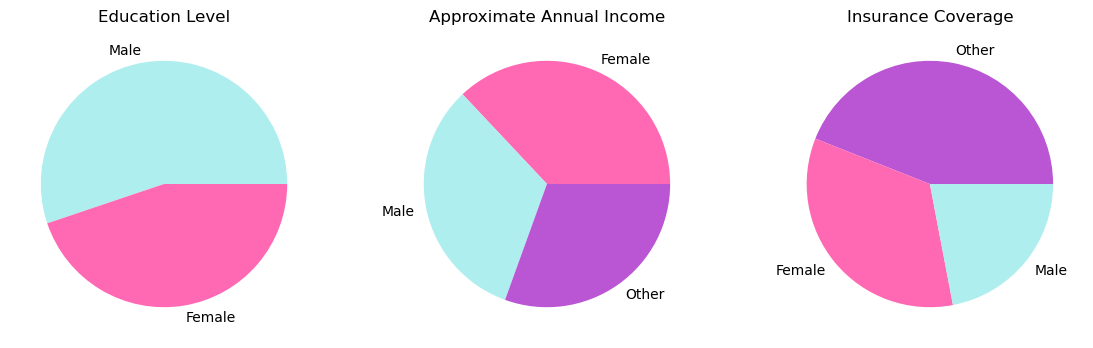

In [101]:
na_analysis = data[['Gender', 'Education Level', 'Approximate Annual Income', 'Insurance Coverage']].fillna('Empty')
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(14,4))
pie_colors = {'Male': 'paleturquoise', 'Female': 'hotpink', 'Other': 'mediumorchid'}

for i in range(3):
    ax = [ax1,ax2,ax3][i]
    col = ['Education Level', 'Approximate Annual Income', 'Insurance Coverage'][i]
    pie_data = na_analysis[na_analysis[col]=='Empty']['Gender'].value_counts().reset_index()
    colors = [pie_colors[label] for label in pie_data['Gender']]
    ax.pie(pie_data.iloc[:,1], labels=pie_data.iloc[:,0], colors=colors)
    ax.set_title(col)
plt.show()

The missing values in these columns don't seem to be dependent on gender, so they could be MCAR

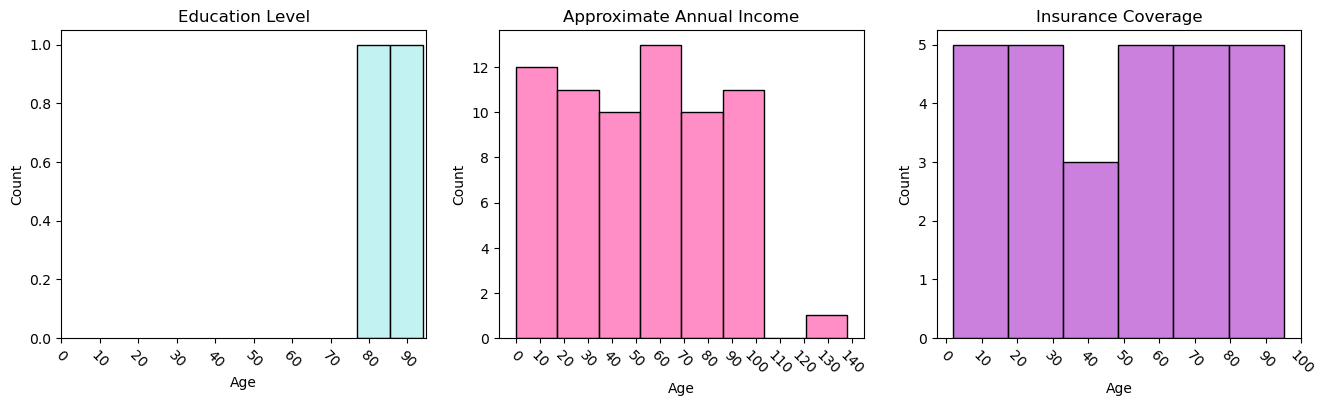

In [102]:
na_analysis = data[['Age', 'Education Level', 'Approximate Annual Income', 'Insurance Coverage']].fillna('Empty')
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(16,4))
colors=['paleturquoise', 'hotpink', 'mediumorchid']

for i in range(3):
    ax = [ax1,ax2,ax3][i]
    col = ['Education Level', 'Approximate Annual Income', 'Insurance Coverage'][i]
    hist_data = na_analysis[na_analysis[col]=='Empty']['Age'].value_counts().reset_index()
    sns.histplot(hist_data, ax=ax, x='Age', color=colors[i])
    ax.set_xticks(np.arange(0,hist_data.sort_values(by='Age').iloc[-1,0]+6,10))
    ax.tick_params(axis='x', labelrotation=-45)
    ax.set_title(col)
plt.show()

The missing values in Education Level seem to be dependent on Age, which makes them MAR, while the other two columns still seem to be MCAR

In [103]:
insurance = data[['Insurance Coverage', 'Insurance Provider']]
insurance['has coverage'] = ~insurance['Insurance Coverage'].isna() & insurance['Insurance Coverage']!=0.0
insurance['has provider'] = ~insurance['Insurance Provider'].isna()

insurance['has both'] = insurance['has coverage'] & insurance['has provider']
insurance['has none'] = ~insurance['has coverage'] & ~insurance['has provider']

insurance = insurance.drop(['Insurance Coverage', 'Insurance Provider'], axis=1)

<Axes: ylabel='count'>

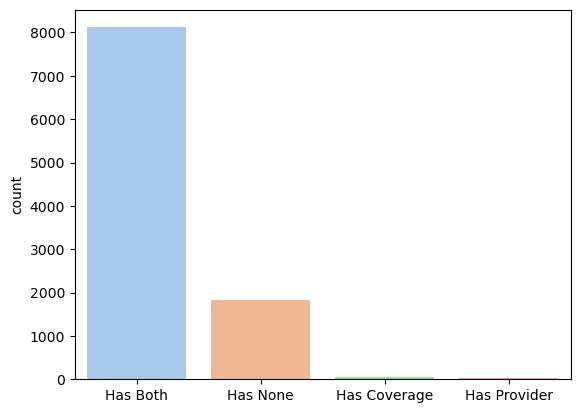

In [104]:
sns.barplot(x=['Has Both', 'Has None', 'Has Coverage', 'Has Provider'], y=pd.Series(insurance.value_counts()), palette='pastel')

Fill Missing At Random Values

In [105]:
data.loc[data['Insurance Provider'].isna(), 'Insurance Coverage'] = (data.loc[data['Insurance Provider'].isna(), 'Insurance Coverage'].fillna(0.0))

In [106]:
median = data.loc[~data['Insurance Provider'].isna(), 'Insurance Coverage'].dropna().median()
data.loc[~data['Insurance Provider'].isna(), 'Insurance Coverage'] = (data.loc[~data['Insurance Provider'].isna(), 'Insurance Coverage'].fillna(median))

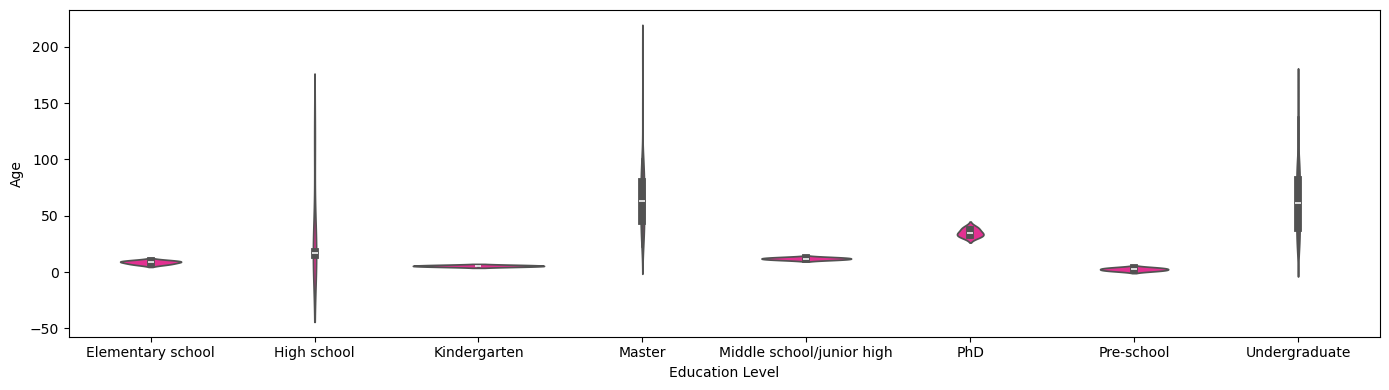

In [107]:
fig, ax = plt.subplots(figsize=(14,4))
education = data.reset_index()[['Education Level', 'Age', 'Patient ID']].drop_duplicates().groupby('Education Level')[['Education Level', 'Age']]
sns.violinplot(data=education.value_counts().reset_index().replace(0, np.nan).dropna(), x='Education Level', y='Age', color='deeppink')
plt.tight_layout()

Fill Missing Completely at Random Values

In [108]:
data[~data['Approximate Annual Income'].isna()]['Approximate Annual Income'].median()


40876.5

In [109]:
median = data[~data['Approximate Annual Income'].isna()]['Approximate Annual Income'].median()
data['Approximate Annual Income'].fillna(median, inplace=True)

In [110]:
data.isna().sum().sort_values(ascending=False)

Family History               1993
Insurance Provider           1860
Education Level                29
Age                             0
Gender                          0
City of Residence               0
Profession                      0
Marital Status                  0
Visit Date                      0
Department                      0
Consultation Duration           0
Satisfaction Level              0
Approximate Annual Income       0
Consultation Price              0
Insurance Coverage              0
dtype: int64

Almost all missing values in coverage are also missing in provider, which also makes it most likely MAR. 
This means that ou

In [111]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         8148 non-null   object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

In [112]:
d_map = {'Age': 'int16', 'Gender': 'category', 'City of Residence': 'category', 'Profession': 'category', 
        'Insurance Provider': 'category', 'Family History': 'category', 'Education Level': 'category', 
        'Marital Status': 'category', 'Department': 'category', 'Consultation Duration': 'int16',
        'Satisfaction Level': 'category', 'Satisfaction Level': 'int8', 'Approximate Annual Income': 'float32',
        'Consultation Price': 'float16', 'Insurance Coverage': 'float16'}
data = data.astype(d_map)

In [113]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  int16         
 1   Gender                     10008 non-null  category      
 2   City of Residence          10008 non-null  category      
 3   Profession                 10008 non-null  category      
 4   Insurance Provider         8148 non-null   category      
 5   Family History             8015 non-null   category      
 6   Education Level            9979 non-null   category      
 7   Marital Status             10008 non-null  category      
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  category      
 10  Consultation Duration      10008 non-null  int16         
 11  Satisfaction Level         10008 non-null  int8          
 12  Approxi